# CS 363M — Wildlife Strike Damage Prediction

**Authors:** Noor Ali, Sammy Thai, Samuel Tsao, Alexander Nguyen

Organized in order by:

1. Data Exploration
2. Data Cleaning
3. Feature Engineering
4. Modeling Approach
5. Submission

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# import seaborn as sns # Is this one allowed??
import numpy as np

# Show matplotlib charts inside the notebook.
%matplotlib inline

# print your pandas version
pd.__version__ 

'3.0.2'

## Load

In [4]:
data = pd.read_csv("data/train.csv")

data.head()

/var/folders/r4/ctd1pj6s2hs6t2wbmr69730w0000gn/T/ipykernel_83948/1671173848.py:1: DtypeWarning: Columns (0: LATITUDE, 1: LONGITUDE, 2: AMO) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/train.csv")


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


# Data Exploration

We looked into many fields including missing values, categorical cardinality, unusual values, and the relationship between redundant fields like `TIME` and `TIME_OF_DAY`. After examining these features, we were able to decide what to drop, clean, transform, or keep for modeling.


In [5]:
'''
Before even running any code, we decided to drop the following columns:

1. LONGITUDE/LATITUDE - We decided to use a broader feature of LOCATION, which is a categorical variable that indicates the general area where the property is located. This is because we believe that the specific longitude and latitude may not be as useful for predicting the target variable as the general location.
2. LUPDATE - This column contains the date of the last update for each property listing. We decided to drop this column because it may not be relevant for our analysis and could potentially introduce noise into our model.
3. TRANSFER - This column is an internal database flag. We decided to drop this column because it is not relevant for our analysis and could potentially introduce noise into our model.
4. PERSON - This column contains the name of the person who filed the report. We decided to drop this column because it is not relevant for our analysis.
5. INDEX_NR - This column contains an index number for each strike report. We decided to drop this column because it is not relevant for our analysis.
6. FLT - This column contains the flight number associated with each strike report. We decided to drop this column because it is not relevant for our analysis and could potentially introduce noise into our model.

We initially thought of dropping redundant columns such as INCIDENT_DATE and INCIDENT_MONTH/YEAR, but we decided to keep them to "merge" them to impute missing values for either column.
'''

'\nBefore even running any code, we decided to drop the following columns:\n\n1. LONGITUDE/LATITUDE - We decided to use a broader feature of LOCATION, which is a categorical variable that indicates the general area where the property is located. This is because we believe that the specific longitude and latitude may not be as useful for predicting the target variable as the general location.\n2. LUPDATE - This column contains the date of the last update for each property listing. We decided to drop this column because it may not be relevant for our analysis and could potentially introduce noise into our model.\n3. TRANSFER - This column is an internal database flag. We decided to drop this column because it is not relevant for our analysis and could potentially introduce noise into our model.\n4. PERSON - This column contains the name of the person who filed the report. We decided to drop this column because it is not relevant for our analysis.\n5. INDEX_NR - This column contains an in

### Finding the percentage of missing data per feature

In [ ]:
# calculate the percentage of missing data
missing_percentage = (data.isnull().sum() / len(data)) * 100

# ignore columns that have all the data
missing_data = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("Percentage of Missing Data per Column:\n")
print(missing_data.round(2).astype(str) + ' %')

Percentage of Missing Data per Column:

BIRD_BAND_NUMBER    99.77 %
ENG_4_POS           98.94 %
ENROUTE_STATE       98.26 %
PRECIPITATION       96.35 %
ENG_3_POS           95.98 %
LOCATION            87.23 %
SPEED               69.04 %
NUM_SEEN            67.89 %
SKY                 53.01 %
FLT                 52.55 %
HEIGHT               50.2 %
TIME_OF_DAY         43.61 %
PHASE_OF_FLIGHT     39.38 %
REG                 38.73 %
AMO                 38.03 %
EMO                 36.84 %
TIME                35.57 %
DISTANCE            33.63 %
COMMENTS            33.56 %
ENG_2_POS           33.37 %
EMA                 33.34 %
AMA                 28.94 %
TYPE_ENG            28.58 %
ENG_1_POS           28.56 %
NUM_ENGS            28.55 %
AC_MASS             28.47 %
AC_CLASS            28.42 %
RUNWAY              24.61 %
LONGITUDE           13.26 %
FAAREGION           13.26 %
STATE               13.26 %
LATITUDE            13.26 %
REMARKS             11.49 %
SIZE                10.91 %
PERSON  

In [ ]:
# Through this analysis, we decided to drop columns that have more than 85% missing data, as it would likely confuse our model.

### Looking at each categorical feature's cardinality

In [8]:
# look at the text columns and count how many different values each one has
cat_columns = data.select_dtypes(include=['object', 'category']).columns
unique_counts = data[cat_columns].nunique().sort_values(ascending=False)

# put the counts into a small table so it is easier to read
cardinality_table = pd.DataFrame({
    'column name': unique_counts.index,
    'unique values': unique_counts.values,
})

print("categorical cardinality (number of unique values per column):\n")
print(cardinality_table.to_string(index=False))

/var/folders/r4/ctd1pj6s2hs6t2wbmr69730w0000gn/T/ipykernel_83948/2242176088.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object', 'category']).columns


Categorical Cardinality (Number of Unique Values per Column):

     Column Name  Unique Values
         REMARKS         250608
        COMMENTS         189613
             REG          44094
   INCIDENT_DATE          13113
             FLT          10649
        LOCATION           9230
         LUPDATE           4720
        LATITUDE           4157
       LONGITUDE           3912
      AIRPORT_ID           2672
         AIRPORT           2672
            TIME           1441
          RUNWAY           1362
      SPECIES_ID            933
         SPECIES            933
            OPID            624
        OPERATOR            616
        AIRCRAFT            615
BIRD_BAND_NUMBER            612
             AMO            118
             AMA             93
           STATE             67
   ENROUTE_STATE             58
          SOURCE             16
 PHASE_OF_FLIGHT             12
   PRECIPITATION             10
       FAAREGION             10
        TYPE_ENG              7
         

In [9]:
# We decided to drop features with a large amount of unique values (> 15000) since they are likely to be less useful for our model and may introduce noise.

### Additionally we wanted to see whether each column had sensible values

In [ ]:
# check whether these columns have sensible values
columns_to_plot = [
    # 'HEIGHT',
    # 'SPEED',
    # 'DISTANCE',
    # 'AC_MASS',
    # 'NUM_ENGS',
    'NUM_SEEN',
    'NUM_STRUCK',
]

for column_name in columns_to_plot:
    non_empty_values = data[column_name].dropna()

    print(column_name)
    print(f"unique values: {non_empty_values.nunique()}")

    print("\nmost common values:")
    print(non_empty_values.value_counts().head(10))

    print("\n")

NUM_SEEN
unique values: 4

most common values:
NUM_SEEN
1                60295
10-Feb           30139
11-100            7221
More than 100      977
Name: count, dtype: int64


NUM_STRUCK
unique values: 4

most common values:
NUM_STRUCK
1                273277
10-Feb            31701
11-100             1502
More than 100        51
Name: count, dtype: int64




In [ ]:
'''
We decided to drop the following columns:

1. NUM_SEEN - This column had lots of dummy values that did not seem correct with dates in the place of values.
2. NUM_STRUCK - This had the similar issue to the NUM_SEEM column.
'''

'\nWe decided to drop the following columns:\n\n1. NUM_SEEN - This column had lots of dummy values being dates or random numbers such as 10-100.\n2. NUM_STRUCK - This column had lots of dummy values being dates or random numbers such as 10-100.\n'

### We noticed the description of time of day and the actual time did not really match up so we decided to look more into this

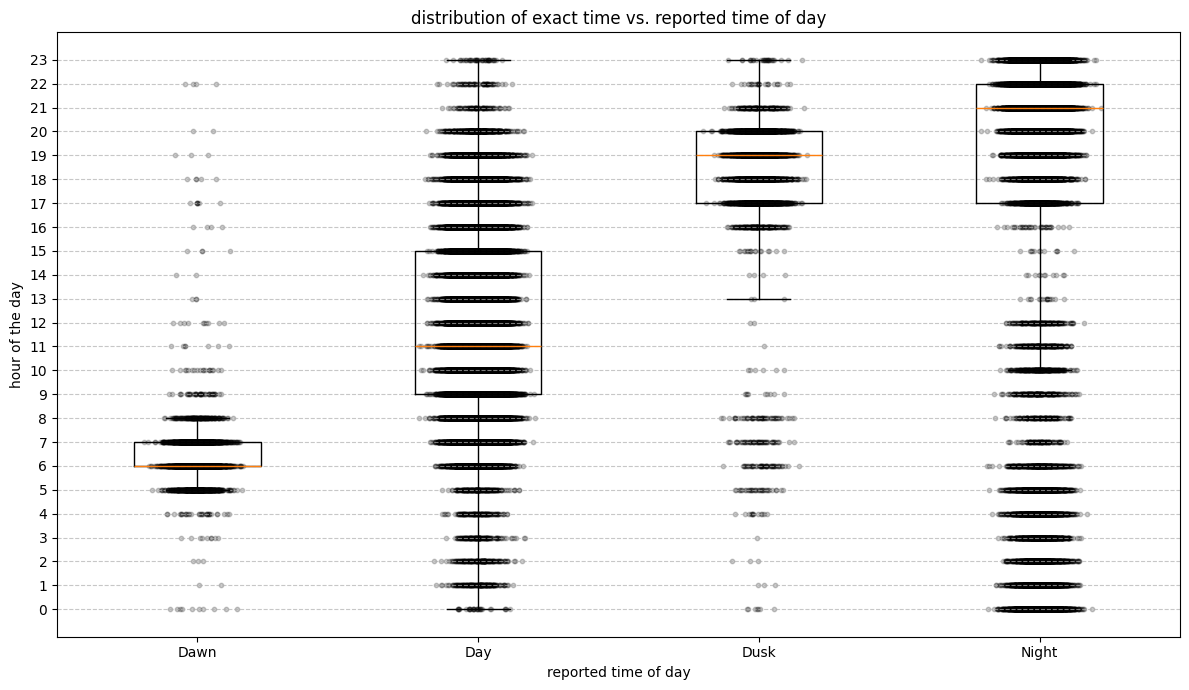

In [ ]:
temp_df = data[['TIME', 'TIME_OF_DAY']].copy()
time_parts = temp_df['TIME'].astype(str).str.split(':', n=1, expand=True)
temp_df['HOUR'] = pd.to_numeric(time_parts[0], errors='coerce')
temp_df = temp_df.dropna(subset=['HOUR', 'TIME_OF_DAY'])

time_order = ['Dawn', 'Day', 'Dusk', 'Night']
grouped_hours = []

for label in time_order:
    hours_for_label = temp_df.loc[temp_df['TIME_OF_DAY'] == label, 'HOUR']
    grouped_hours.append(hours_for_label)

fig, ax = plt.subplots(figsize=(12, 7))
ax.boxplot(grouped_hours, tick_labels=time_order, showfliers=False)

# add the raw points so we can see how spread out each group is
for position, hours in enumerate(grouped_hours, start=1):
    x_values = np.random.normal(position, 0.05, size=len(hours))
    ax.scatter(x_values, hours, color='black', alpha=0.2, s=10)

ax.set_xlabel('Reported time of day')
ax.set_ylabel('Hour of the day')
ax.set_yticks(range(0, 24))
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [13]:
# We noticed that the TIME_OF_DAY column does not correlate with the TIME column, which is a more specific feature. This suggests that the TIME_OF_DAY column may not be very useful for our model and could potentially introduce noise.


There are also a plethera of other things we began to notice over time.
- The latitude and longitude fields are often very close to the airport location so the latitude and longitude field are not always going to be useful.
- There are other redundant fields like the INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR where we can capture all of this in a single field or seperate it to try and capture seasonal patterns. So, we thought of using cos and sin on the month. This also led to the idea of using it on the latitude and longitude to try and understand geospatial regions.
- We noticed that the data had a very low amount of positive records (~6%). This meant that we had to focus on other metrics since accuracy was not going to be representative. 
- Fields like SPECIES_ID and SPECIES reveal the same info, same with the field OPID and OPERATOR. So, merging these is probably the best to reduce the noise and duplicate fields.
- Thought about trying to extract key words from the comments and remarks like the word Damage as an example, felt like this would overfit.

These are some of the few other things we noticed over time.

# Data Cleaning

This section handles data quality issues found during exploration and responds accordingly to clean up the data the way we saw best.


### Drop noisy, sparse, or leaky columns

We remove fields that are mostly missing, just text, or likely to leak information from after the strike was reported. Examples include REMARKS, COMMENTS, NUM_STRUCK, PERSON, and report/update metadata.


In [ ]:
cols_to_drop = [
    "REMARKS",
    "NUM_STRUCK",
    "LOCATION",
    "ENG_3_POS",
    "BIRD_BAND_NUMBER",
    "ENG_4_POS", # very empty
    "ENROUTE_STATE",
    "PRECIPITATION", # tried with and without
    "COMMENTS",
    "TRANSFER",
    "SOURCE",
    "LUPDATE", # last updated time
    "RUNWAY", # runway number (not useful)
    "FLT", # flight number
    "AIRCRAFT", # name of the aircraft in text
    "INDEX_NR", # index number
    "REG", 
    "PERSON",
    "NUM_SEEN",
    "NUM_STRUCK"
]


df = data.drop(columns=cols_to_drop, errors="ignore")

df.head()

,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,STATE,...,DISTANCE,SKY,SPECIES_ID,SPECIES,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,WARNED,SIZE,INDICATED_DAMAGE
0,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,PR,...,NaN,Some Cloud,UNKBS,Unknown bird - small,0,1,0,No,Small,0
1,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,FN,...,0.0,NaN,UNKBM,Unknown bird - medium,0,0,0,Unknown,Medium,0
2,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,KY,...,8.0,NaN,UNKBL,Unknown bird - large,0,0,0,No,Large,1
3,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,CA,...,0.0,NaN,NE120,Western gull,0,1,0,Unknown,Medium,0
4,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,HI,...,0.0,Some Cloud,R1101,American barn owl,0,0,0,No,Medium,0


## Handle missing categorical values

For categorical fields, missing values are converted to an explicit Unknown category. Numeric values are left as missing for now so the encoder/imputer can learn medians from training data only.


In [ ]:
from sklearn.impute import SimpleImputer

# for text columns, use an "Unknown" category instead of leaving blanks
cat_cols = df.select_dtypes(include=["str", "object", "category"]).columns
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

# for number columns, mark which rows were missing before filling them in
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isna().any():
        df[col + "_MISSING"] = df[col].isna().astype(int)

# fill empty numbers with median
num_cols = df.select_dtypes(include=[np.number]).columns
median_imputer = SimpleImputer(strategy="median")
df[num_cols] = median_imputer.fit_transform(df[num_cols])


# Feature Engineering

After, we cleaned the data, there was still some changes we had to make to the features in an attempt to get as much information out of them as possible.


## Create date and time features

We changed the raw date and time fields are transformed into values we felt would help the model better understand the data.


In [ ]:
# turn the date into simpler numeric pieces the model can use
incident_dt = pd.to_datetime(df["INCIDENT_DATE"], format="mixed", dayfirst=False, errors="coerce")
anchor = incident_dt.min()

df["INCIDENT_DATE"] = (incident_dt - anchor).dt.days
df["INCIDENT_MONTH"] = incident_dt.dt.month.fillna(-1).astype(int)
df["INCIDENT_DAYOFWEEK"] = incident_dt.dt.dayofweek.fillna(-1).astype(int)
df["INCIDENT_DAYOFYEAR"] = incident_dt.dt.dayofyear.fillna(-1).astype(int)
df = df.drop(columns=["INCIDENT_YEAR"], errors="ignore")

# convert time from strings like "14:30" into minutes after midnight
split_time = df["TIME"].astype(str).str.split(":", n=1, expand=True)
hour = pd.to_numeric(split_time[0], errors="coerce")
minute = pd.to_numeric(split_time[1], errors="coerce").fillna(0)

df["TIME"] = (hour * 60 + minute).where(hour.between(0, 23) & minute.between(0, 59))
df["TIME_HOUR"] = hour
df["TIME_MINUTE"] = minute

# 1440 is the number of minutes in a day and 2*pi is one full circle
# this lets the model understand that 11:59 pm is close to 12:00 am
df["TIME_SIN"] = np.sin(2 * np.pi * df["TIME"] / 1440)
df["TIME_COS"] = np.cos(2 * np.pi * df["TIME"] / 1440)

# we considered turning latitude/longitude into globe coordinates, but did not use it in the final model
# lat_rad = np.radians(df["LATITUDE"])
# lon_rad = np.radians(df["LONGITUDE"])
# df["GEO_X"] = np.cos(lat_rad) * np.cos(lon_rad)
# df["GEO_Y"] = np.cos(lat_rad) * np.sin(lon_rad)
# df["GEO_Z"] = np.sin(lat_rad)
df = df.drop(columns=["LATITUDE", "LONGITUDE"], errors="ignore")

# this field did not look useful from the earlier data exploration
df = df.drop(columns=["TIME_OF_DAY"], errors="ignore")

# keep the id columns instead of the longer repeated names
df = df.drop(columns=["AIRPORT"], errors="ignore")
df = df.drop(columns=["OPERATOR"], errors="ignore")
df = df.drop(columns=["SPECIES"], errors="ignore")



In [16]:
df.head()

,INCIDENT_DATE,INCIDENT_MONTH,TIME,AIRPORT_ID,LATITUDE,LONGITUDE,STATE,FAAREGION,OPID,AMA,...,WARNED,SIZE,INDICATED_DAMAGE,INCIDENT_DAYOFWEEK,INCIDENT_IS_WEEKEND,INCIDENT_DAYOFYEAR,TIME_HOUR,TIME_MINUTE,TIME_SIN,TIME_COS
0,1441,12,NaN,TJSJ,18.43942,-66.00183,PR,ASO,AAL,148,...,No,Small,0,0,0,347,NaN,0.0,NaN,NaN
1,7335,2,300.0,WMKK,2.745578,101.709917,FN,FGN,FDX,583,...,Unknown,Medium,0,0,0,32,5.0,0.0,0.965926,0.258819
2,8163,5,120.0,KSDF,38.17439,-85.736,KY,ASO,UPS,04A,...,No,Large,1,2,0,130,2.0,0.0,0.500000,0.866025
3,4662,10,NaN,KLAX,33.94254,-118.40807,CA,AWP,UNK,NaN,...,Unknown,Medium,0,1,0,281,NaN,0.0,NaN,NaN
4,2589,2,NaN,PHLI,21.97598,-159.33896,HI,AWP,1AAH,148,...,No,Medium,0,0,0,34,NaN,0.0,NaN,NaN


## Encode categorical features and impute numeric values

High-cardinality categorical columns are frequency encoded, while smaller categorical columns are one-hot encoded.


In [ ]:
# split out the label column from the rest of the data
TARGET = "INDICATED_DAMAGE"
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET], errors="ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# keep the same damage/no-damage balance in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.copy()
X_test = X_test.copy()

# columns with words/categories need to be converted before the model can use them
categorical_cols = list(X_train.select_dtypes(include=["str", "object", "category"]).columns)

for c in categorical_cols:
    X_train[c] = X_train[c].fillna("Unknown").astype(str)
    X_test[c] = X_test[c].fillna("Unknown").astype(str)

# columns with a lot of unique values get frequency encoded instead of one-hot encoded
high_card_cutoff = 30
high_card_cols = []
low_card_cols = []

for c in categorical_cols:
    unique_values = X_train[c].nunique(dropna=False)
    if unique_values > high_card_cutoff:
        high_card_cols.append(c)
    else:
        low_card_cols.append(c)

for c in high_card_cols:
    frequencies = X_train[c].value_counts(normalize=True)
    X_train[c] = X_train[c].map(frequencies).fillna(0.0)
    X_test[c] = X_test[c].map(frequencies).fillna(0.0)

# smaller categorical columns are easier to one-hot encode
if low_card_cols:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoder.fit(X_train[low_card_cols])

    train_encoded = pd.DataFrame(
        encoder.transform(X_train[low_card_cols]),
        columns=encoder.get_feature_names_out(low_card_cols),
        index=X_train.index,
    )
    test_encoded = pd.DataFrame(
        encoder.transform(X_test[low_card_cols]),
        columns=encoder.get_feature_names_out(low_card_cols),
        index=X_test.index,
    )

    X_train = X_train.drop(columns=low_card_cols).join(train_encoded)
    X_test = X_test.drop(columns=low_card_cols).join(test_encoded)

print("X_train", X_train.shape, "\n X_test", X_test.shape, "\n Categorical Columns:", categorical_cols)


X_train (245742, 91) | X_test (61436, 91) | categorical columns: ['AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'STATE', 'FAAREGION', 'OPID', 'AMA', 'AMO', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SKY', 'SPECIES_ID', 'WARNED', 'SIZE']


In [19]:
X_train.head(10)

,INCIDENT_DATE,INCIDENT_MONTH,TIME,AIRPORT_ID,LATITUDE,LONGITUDE,STATE,OPID,AMA,AMO,...,AC_MASS_MISSING,NUM_ENGS_MISSING,ENG_1_POS_MISSING,ENG_2_POS_MISSING,HEIGHT_MISSING,SPEED_MISSING,DISTANCE_MISSING,TIME_HOUR_MISSING,TIME_SIN_MISSING,TIME_COS_MISSING
158116,7885.0,8.0,620.0,0.006246,0.006246,0.006246,0.089570,0.091039,0.259048,0.028090,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9956,9750.0,9.0,740.0,0.003178,0.003178,0.003178,0.046944,0.024314,0.063591,0.037474,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
204735,10895.0,11.0,1215.0,0.005978,0.005978,0.005978,0.073199,0.072820,0.123052,0.048775,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
168338,11577.0,9.0,770.0,0.002869,0.002869,0.002869,0.008350,0.282268,0.289397,0.380281,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
92239,10067.0,7.0,770.0,0.002124,0.002124,0.002124,0.003345,0.282268,0.289397,0.380281,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
272246,10858.0,9.0,620.0,0.132301,0.132493,0.132505,0.132493,0.007068,0.063591,0.015382,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
118850,8767.0,1.0,770.0,0.003174,0.003174,0.003174,0.005233,0.282268,0.289397,0.380281,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
197497,6037.0,7.0,770.0,0.004415,0.004415,0.004415,0.016509,0.005376,0.259048,0.012045,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
91609,7866.0,7.0,1190.0,0.001701,0.001701,0.001701,0.073199,0.002413,0.063591,0.037474,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
39015,10386.0,6.0,770.0,0.001453,0.001453,0.001453,0.046944,0.004297,0.069235,0.019179,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0


# Modeling Approach

We tried a few different models like Naive Bayes and KNN for fun but they weren't great.

Here we displayed our two best models.
We had a feeling that a boosted tree model was the best so we spent the most time on it. The gradient boosting model uses a smaller sampled grid search for hyperparameter tuning, and we used a HistGradientBoostingClassifier because it gave us the best results from the ones we tried individually.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score

# tune on a smaller sample first so this cell does not take forever
tune_size = 50000
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=tune_size,
    stratify=y_train,
    random_state=42,
)

inner_cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=1)
outer_cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=2)

param_grid = {
    "learning_rate": [0.03, 0.05],
    "max_leaf_nodes": [15, 31, 63],
    "max_iter": [300, 500],
    "l2_regularization": [0.05, 0.1],
}

base_clf = HistGradientBoostingClassifier(
    class_weight="balanced",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
)

grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    scoring="average_precision",
    cv=inner_cv,
    n_jobs=1,
    refit=True,
    verbose=1,
)

grid_search.fit(X_tune, y_tune)
print("Best settings:", grid_search.best_params_)
print("Best inner cv pr-auc:", grid_search.best_score_)

outer_model = HistGradientBoostingClassifier(
    **grid_search.best_params_,
    class_weight="balanced",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
)
outer_scores = cross_val_score(
    outer_model,
    X_tune,
    y_tune,
    scoring="average_precision",
    cv=outer_cv,
    n_jobs=1,
)
print("Outer cv pr-auc:", outer_scores.mean(), " std: ", outer_scores.std())

# once we have the best settings, train the model again on all the training rows
final_clf = HistGradientBoostingClassifier(
    **grid_search.best_params_,
    class_weight="balanced",
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
)
final_clf.fit(X_train, y_train)

pred_proba = final_clf.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
print("PR-AUC:", average_precision_score(y_test, pred_proba))
print(classification_report(y_test, final_clf.predict(X_test), digits=4))

# this lets the later validation/submission cells use only this model if we want
models = [
    ("hgb", final_clf, 1.0)
]


Tuning on 50000 rows instead of all 245742 training rows.
Fitting 2 folds for each of 36 candidates, totalling 72 fits
Best hyperparameters: {'l2_regularization': 0.1, 'learning_rate': 0.05, 'max_iter': 300, 'max_leaf_nodes': 15}
Best sampled CV average precision: 0.46116793133576656
ROC-AUC: 0.9063671557043532
PR-AUC: 0.5083492707330359
              precision    recall  f1-score   support

           0     0.9850    0.8253    0.8981     57531
           1     0.2405    0.8154    0.3715      3905

    accuracy                         0.8246     61436
   macro avg     0.6128    0.8203    0.6348     61436
weighted avg     0.9377    0.8246    0.8646     61436



## Ensemble model

The ensemble averages predictions from HistGradientBoosting, CatBoost, XGBoost, AdaBoost, RandomForest, and ExtraTrees. These models are trained on the same processed feature matrix so their predictions can be compared fairly.


In [ ]:
# took many boosted trees and combined them with weights that best show how they perform individually.
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, classification_report, f1_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

base_tree = DecisionTreeClassifier(
    max_depth=12,
    min_samples_leaf=120,
    class_weight="balanced",
    random_state=42,
)

models = [
    (
        "hgb",
        HistGradientBoostingClassifier(
            max_iter=500,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            class_weight="balanced",
            random_state=42,
        ),
        0.25,
    ),
    (
        "cat",
        CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            l2_leaf_reg=3.0,
            loss_function="Logloss",
            auto_class_weights="Balanced",
            random_seed=42,
            verbose=0,
            allow_writing_files=False,
        ),
        0.20,
    ),
    (
        "xgb",
        XGBClassifier(
            n_estimators=450,
            learning_rate=0.04,
            max_depth=4,
            min_child_weight=8,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=5.0,
            scale_pos_weight=6.0,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=42,
        ),
        0.20,
    ),
    (
        "ada",
        AdaBoostClassifier(
            estimator=base_tree,
            n_estimators=180,
            learning_rate=0.08,
            random_state=42,
        ),
        0.20,
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=250,
            max_depth=20,
            min_samples_leaf=25,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
        ),
        0.10,
    ),
    (
        "et",
        ExtraTreesClassifier(
            n_estimators=250,
            max_depth=22,
            min_samples_leaf=25,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
        ),
        0.05,
    ),
]


In [26]:
# check the ensemble on the same validation split from earlier
valid_scores = np.zeros(len(X_test))
total_weight = 0

for name, model, weight in models:
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    valid_scores += weight * proba
    total_weight += weight
    print(f"{name}: roc-auc={roc_auc_score(y_test, proba):.5f}, pr-auc={average_precision_score(y_test, proba):.5f}")

valid_scores = valid_scores / total_weight
valid_pred = (valid_scores >= 0.5).astype(int)

print("ensemble roc-auc:", roc_auc_score(y_test, valid_scores))
print("ensemble pr-auc:", average_precision_score(y_test, valid_scores))
print("ensemble f1:", f1_score(y_test, valid_pred))
print(classification_report(y_test, valid_pred, digits=4))

hgb: ROC-AUC=0.90750, PR-AUC=0.51332
cat: ROC-AUC=0.90703, PR-AUC=0.51429
xgb: ROC-AUC=0.90727, PR-AUC=0.51623
ada: ROC-AUC=0.89948, PR-AUC=0.42473
rf: ROC-AUC=0.90141, PR-AUC=0.49101
et: ROC-AUC=0.89522, PR-AUC=0.46851
ensemble ROC-AUC: 0.9081660656100988
ensemble PR-AUC: 0.5145292227257892
ensemble F1@18%: 0.40379603020784605
              precision    recall  f1-score   support

           0     0.9825    0.8603    0.9173     57531
           1     0.2732    0.7736    0.4038      3905

    accuracy                         0.8548     61436
   macro avg     0.6278    0.8170    0.6606     61436
weighted avg     0.9374    0.8548    0.8847     61436



# Making Submission


In [ ]:
test_data = pd.read_csv("data/test.csv")
test_ids = test_data["INDEX_NR"]


test_df = test_data.drop(columns=cols_to_drop, errors="ignore")


# for text columns, use an "Unknown" category instead of leaving blanks
cat_cols = test_df.select_dtypes(include=["str", "object", "category"]).columns
for col in cat_cols:
    test_df[col] = test_df[col].fillna("Unknown")


# for number columns, mark which rows were missing before filling them in
num_cols = test_df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if test_df[col].isna().any():
        test_df[col + "_MISSING"] = test_df[col].isna().astype(int)


# turn the date into simpler numeric pieces the model can use
incident_dt = pd.to_datetime(test_df["INCIDENT_DATE"], format="mixed", dayfirst=False, errors="coerce")
test_df["INCIDENT_DATE"] = (incident_dt - anchor).dt.days
test_df["INCIDENT_MONTH"] = incident_dt.dt.month.fillna(-1).astype(int)
test_df["INCIDENT_DAYOFWEEK"] = incident_dt.dt.dayofweek.fillna(-1).astype(int)
test_df["INCIDENT_DAYOFYEAR"] = incident_dt.dt.dayofyear.fillna(-1).astype(int)
test_df = test_df.drop(columns=["INCIDENT_YEAR"], errors="ignore")


# convert time from strings like "14:30" into minutes after midnight
split_time = test_df["TIME"].astype(str).str.split(":", n=1, expand=True)
hour = pd.to_numeric(split_time[0], errors="coerce")
minute = pd.to_numeric(split_time[1], errors="coerce").fillna(0)

test_df["TIME"] = (hour * 60 + minute).where(hour.between(0, 23) & minute.between(0, 59))
test_df["TIME_HOUR"] = hour
test_df["TIME_MINUTE"] = minute

# 1440 is the number of minutes in a day and 2*pi is one full circle
# this lets the model understand that 11:59 pm is close to 12:00 am
test_df["TIME_SIN"] = np.sin(2 * np.pi * test_df["TIME"] / 1440)
test_df["TIME_COS"] = np.cos(2 * np.pi * test_df["TIME"] / 1440)


# we considered turning latitude/longitude into globe coordinates, but did not use it in the final model
# lat_rad = np.radians(test_df["LATITUDE"])
# lon_rad = np.radians(test_df["LONGITUDE"])
# test_df["GEO_X"] = np.cos(lat_rad) * np.cos(lon_rad)
# test_df["GEO_Y"] = np.cos(lat_rad) * np.sin(lon_rad)
# test_df["GEO_Z"] = np.sin(lat_rad)
test_df = test_df.drop(columns=["LATITUDE", "LONGITUDE"], errors="ignore")

# this field did not look useful from the earlier data exploration
test_df = test_df.drop(columns=["TIME_OF_DAY"], errors="ignore")

# keep the id columns instead of the longer repeated names
test_df = test_df.drop(columns=["AIRPORT"], errors="ignore")
test_df = test_df.drop(columns=["OPERATOR"], errors="ignore")
test_df = test_df.drop(columns=["SPECIES"], errors="ignore")


test_df = test_df.reindex(columns=X.columns)


X_full = X.copy()
X_submit = test_df.copy()


# columns with words/categories need to be converted before the model can use them
categorical_cols = list(X_full.select_dtypes(include=["str", "object", "category"]).columns)

for c in categorical_cols:
    X_full[c] = X_full[c].fillna("Unknown").astype(str)
    X_submit[c] = X_submit[c].fillna("Unknown").astype(str)


# fill empty numbers with median
num_cols = X_full.select_dtypes(include=[np.number]).columns
median_imputer = SimpleImputer(strategy="median")
X_full[num_cols] = median_imputer.fit_transform(X_full[num_cols])
X_submit[num_cols] = median_imputer.transform(X_submit[num_cols])


# columns with a lot of unique values get frequency encoded instead of one-hot encoded
high_card_cutoff = 30
high_card_cols = []
low_card_cols = []

for c in categorical_cols:
    unique_values = X_full[c].nunique(dropna=False)
    if unique_values > high_card_cutoff:
        high_card_cols.append(c)
    else:
        low_card_cols.append(c)

for c in high_card_cols:
    frequencies = X_full[c].value_counts(normalize=True)
    X_full[c] = X_full[c].map(frequencies).fillna(0.0)
    X_submit[c] = X_submit[c].map(frequencies).fillna(0.0)


# smaller categorical columns are easier to one-hot encode
if low_card_cols:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoder.fit(X_full[low_card_cols])

    full_encoded = pd.DataFrame(
        encoder.transform(X_full[low_card_cols]),
        columns=encoder.get_feature_names_out(low_card_cols),
        index=X_full.index,
    )
    submit_encoded = pd.DataFrame(
        encoder.transform(X_submit[low_card_cols]),
        columns=encoder.get_feature_names_out(low_card_cols),
        index=X_submit.index,
    )

    X_full = X_full.drop(columns=low_card_cols).join(full_encoded)
    X_submit = X_submit.drop(columns=low_card_cols).join(submit_encoded)


print("X_full", X_full.shape, "\n X_submit", X_submit.shape, "\n Categorical Columns:", categorical_cols)

/var/folders/r4/ctd1pj6s2hs6t2wbmr69730w0000gn/T/ipykernel_83948/2671099972.py:1: DtypeWarning: Columns (0: LATITUDE, 1: LONGITUDE, 2: AMO, 3: BIRD_BAND_NUMBER) have mixed types. Specify dtype option on import or set low_memory=False.
  test_data = pd.read_csv("data/test.csv")


,INCIDENT_DATE,INCIDENT_MONTH,TIME,AIRPORT_ID,LATITUDE,LONGITUDE,STATE,FAAREGION,OPID,AMA,...,REMAINS_SENT,WARNED,SIZE,INCIDENT_DAYOFWEEK,INCIDENT_IS_WEEKEND,INCIDENT_DAYOFYEAR,TIME_HOUR,TIME_MINUTE,TIME_SIN,TIME_COS
0,9702,7,495.0,KDTW,42.21206,-83.34884,MI,AGL,EDV,188,...,0,Unknown,Small,1,0,208,8.0,15.0,0.831470,-0.555570
1,907,6,NaN,KMSY,29.99339,-90.25803,LA,ASW,AAL,148,...,0,No,Small,5,1,179,NaN,0.0,NaN,NaN
2,12372,11,1057.0,KIND,39.71733,-86.29438,IN,AGL,UAL,04A,...,0,Unknown,Small,4,0,321,17.0,37.0,-0.994969,-0.100188
3,7104,6,645.0,PHMK,21.15289,-157.09626,HI,AWP,BUG,226,...,0,No,Small,0,0,166,10.0,45.0,0.321439,-0.946930
4,300,10,749.0,KBED,42.46995,-71.28903,MA,ANE,UNK,123,...,0,Yes,Medium,0,0,302,12.0,29.0,-0.126199,-0.992005


## Create the submission file

The final submission uses the target positive rate threshold to convert ensemble scores into 0/1 predictions.


In [29]:
output_path = "ensemble_submission.csv"
test_scores = np.zeros(len(X_submit))
total_weight = 0

for name, model, weight in models:
    model.fit(X_full, y)
    test_scores += weight * model.predict_proba(X_submit)[:, 1]
    total_weight += weight
    print(f"final {name} fitted")

test_scores = test_scores / total_weight
test_pred = (test_scores >= 0.5).astype(int)

submission = pd.DataFrame({"INDEX_NR": test_ids, TARGET: test_pred})
submission.to_csv(output_path, index=False)

print(f"wrote {output_path}")
print(f"positives={test_pred.sum()}, positive_rate={test_pred.mean():.6f}")

final hgb fitted
final cat fitted
final xgb fitted
final ada fitted
final rf fitted
final et fitted
Wrote ensemble_submission.csv
positives=6144, positive_rate=0.180012
